# QSVT Linear Solver (2×2 system, exact inverse via P(x)=x)

This notebook demonstrates a minimal **QSVT linear solver** example.

We choose a Hermitian matrix A with eigenvalues ±1:

    A² = I  →  A⁻¹ = A

Therefore the polynomial

    P(x) = x

exactly implements the inverse on the spectrum.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.matrices import pauli_x
from qsvt.polynomials import eval_polynomial, polynomial_parity
from qsvt.qsvt import (
    apply_qsvt_to_embedded_vector,
    qsvt_top_left_block,
)

## Define the linear system A x = b

In [2]:
A = pauli_x()

b = np.array([1.0, 2.0], dtype=float)

x_classical = np.linalg.solve(A, b)

x_classical_normalized = x_classical / np.linalg.norm(x_classical)

eigvals, _ = np.linalg.eigh(A)

print(f"A = {A}")
print(f"\nb = {b}")
print(f"\nClassical solution: {x_classical}")
print(f"\nNormalized classical solution: {x_classical_normalized}")
print(f"\nEigenvalues of A: {eigvals}")

A = [[0. 1.]
 [1. 0.]]

b = [1. 2.]

Classical solution: [2. 1.]

Normalized classical solution: [0.89442719 0.4472136 ]

Eigenvalues of A: [-1.  1.]


## Polynomial implementing the inverse

Polynomial coefficients: [0. 1.]
Parity [polynomial parity]: odd


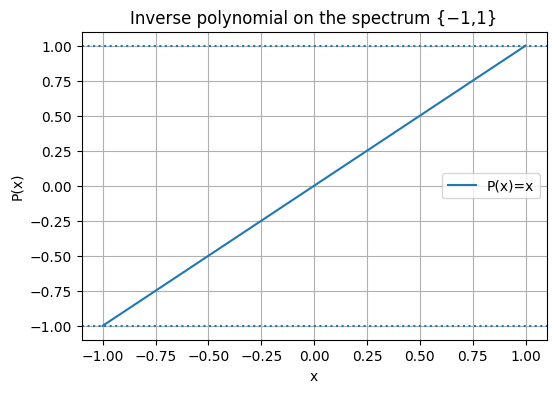

In [3]:
poly = np.array([0.0, 1.0])

print("Polynomial coefficients:", poly)

print("Parity [polynomial parity]:", polynomial_parity(poly))


xs = np.linspace(-1, 1, 200)

plt.figure(figsize=(6, 4))

plt.plot(xs, eval_polynomial(poly, xs), label="P(x)=x")

plt.axhline(-1, linestyle=":")
plt.axhline(1, linestyle=":")

plt.xlabel("x")
plt.ylabel("P(x)")

plt.title("Inverse polynomial on the spectrum {−1,1}")

plt.grid(True)

plt.legend()

plt.show()

Because eigenvalues are ±1, we have

    P(λ) = λ = 1/λ

so QSVT exactly implements the inverse.

## Compute QSVT operator

In [4]:
encoding_wires = [0, 1]
wire_order = [0, 1]

P_of_A = qsvt_top_left_block(
    A,
    poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)


print("QSVT top-left block P(A):")
print(np.round(P_of_A, 6))


print("\nDirect A:")
print(A)

QSVT top-left block P(A):
[[0.+0.e+00j 1.+1.e-06j]
 [1.+1.e-06j 0.+0.e+00j]]

Direct A:
[[0. 1.]
 [1. 0.]]


For this matrix, we expect

    P(A) = A = A⁻¹

## Solve the system using QSVT

In [5]:
x_qsvt = apply_qsvt_to_embedded_vector(
    A,
    b,
    poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)


x_qsvt_normalized = x_qsvt / np.linalg.norm(x_qsvt)


print(f"QSVT solution (normalized): {x_qsvt_normalized}")
print(f"\nClassical solution (normalized): {x_classical_normalized}")

QSVT solution (normalized): [0.89442719+1.26489707e-06j 0.4472136 +6.32448537e-07j]

Classical solution (normalized): [0.89442719 0.4472136 ]


Compare amplitudes

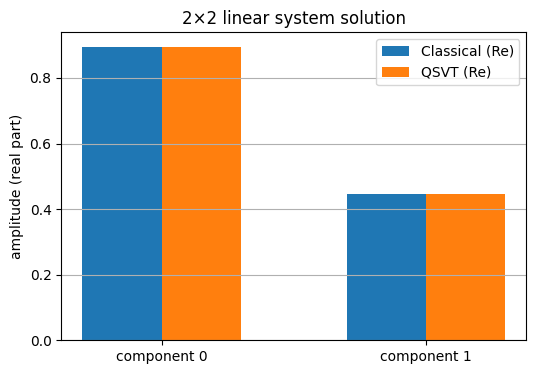

In [6]:
labels = ["component 0", "component 1"]

plt.figure(figsize=(6, 4))

plt.bar(
    np.arange(2) - 0.15,
    np.real(x_classical_normalized),
    width=0.3,
    label="Classical (Re)",
)

plt.bar(
    np.arange(2) + 0.15,
    np.real(x_qsvt_normalized),
    width=0.3,
    label="QSVT (Re)",
)

plt.xticks(np.arange(2), labels)

plt.ylabel("amplitude (real part)")

plt.title("2×2 linear system solution")

plt.grid(True, axis="y")

plt.legend()

plt.show()

## Interpretation

Because the spectrum is {−1,1}, the inverse is exactly representable by a
degree-1 polynomial.

This makes the example mathematically trivial but useful pedagogically:

it shows how a polynomial applied via QSVT can act as a matrix inverse.

## Validation

Compact checks for the expected tutorial behavior.


In [7]:
assert polynomial_parity(poly) == "odd"
assert np.allclose(P_of_A, A, atol=1e-5)
assert np.abs(np.vdot(x_classical_normalized, x_qsvt_normalized)) > 1.0 - 1e-9

print(f"block_max_error: {np.max(np.abs(P_of_A - A)):.3e}")
print(
    f"solution_overlap: {np.abs(np.vdot(x_classical_normalized, x_qsvt_normalized)):.12f}"
)
print("validation: passed")

block_max_error: 1.414e-06
solution_overlap: 1.000000000000
validation: passed
